In [ ]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, accuracy_score
from skimage import io
from sklearn.metrics import roc_curve, auc, confusion_matrix, ConfusionMatrixDisplay
from IPython.display import display


2026-05-12 21:51:13.928762: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778622674.319231      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778622674.435266      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778622675.455847      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778622675.455872      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778622675.455875      57 computation_placer.cc:177] computation placer alr

# VALIDATION CONFIGURATION VISUALIZING AND GRAPHS

In [3]:
SEED = 42

### TEST PHASE; VALIDATION CHECK

In [4]:
TRAIN_PATH = '/kaggle/input/competitions/histopathologic-cancer-detection/train/'
TEST_PATH  = '/kaggle/input/competitions/histopathologic-cancer-detection/test/'
LABELS_CSV = '/kaggle/input/competitions/histopathologic-cancer-detection/train_labels.csv'

labels_df = pd.read_csv(LABELS_CSV)
train_files = [os.path.join(TRAIN_PATH, f'{x}.tif') for x in labels_df.id]
train_labels = labels_df.label.values

x_train, x_val, y_train, y_val = train_test_split(
    train_files, train_labels, test_size=0.2, stratify=train_labels, random_state=SEED
)

Set UP and Testing Data Pipeline

In [ ]:
def decode_image_python(path_tensor):
    path_str = path_tensor.numpy().decode("utf-8")
    img = io.imread(path_str)
    
    # Channel correction (done in NumPy since we are in pure Python here)
    if img.ndim == 2:
        img = np.stack([img, img, img], axis=-1)
    elif img.shape[-1] == 4:
        img = img[..., :3]
    elif img.ndim == 2 and img.shape[-1] == 3:
        img = np.expand_dims(img, axis=1)
        
    return img.astype(np.float32)


def process_path_test(path, label=None):
    # Shield the python code from the Graph
    img = tf.py_function(decode_image_python, [path], tf.float32)
    
    # Immediately lock in the known shape to prevent TF graph errors
    img.set_shape((96, 96, 3)) 
    
    # Resize and Normalize
    img = tf.image.resize(img, [96, 96])
    img = img / 255.0
    
    if label is not None:
        return img, tf.cast(label, tf.int32)
    return img


def make_test_dataset(files, labels=None, batch_size=32):
    """Creates a memory-safe pipeline for evaluation or testing."""
    if labels is not None:
        # Phase 1: Local Comprobation (With Labels)
        ds = tf.data.Dataset.from_tensor_slices((files, labels))
        ds = ds.map(process_path_test, num_parallel_calls=tf.data.AUTOTUNE)
    else:
        # Phase 2: Kaggle Submission (Without Labels)
        ds = tf.data.Dataset.from_tensor_slices(files)
        ds = ds.map(lambda x: process_path_test(x), num_parallel_calls=tf.data.AUTOTUNE)
        
    return ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)

In [ ]:
# Define the Custom Layers so Keras knows how to rebuild them
class BDCGFusionLayer(tf.keras.layers.Layer):
    def __init__(self, embed_dim=64, num_heads=4, **kwargs):
        super(BDCGFusionLayer, self).__init__(**kwargs)
        self.embed_dim = embed_dim
        self.num_heads = num_heads
        self.mha_g2l = tf.keras.layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)
        self.mha_l2g = tf.keras.layers.MultiHeadAttention(num_heads=num_heads, key_dim=embed_dim)
        self.norm_l = tf.keras.layers.LayerNormalization(epsilon=1e-5)
        self.norm_g = tf.keras.layers.LayerNormalization(epsilon=1e-5)

    def call(self, local_seq, global_seq):
        refined_local = self.mha_g2l(query=local_seq, value=global_seq, key=global_seq)
        out_local = self.norm_l(local_seq + refined_local)
        refined_global = self.mha_l2g(query=global_seq, value=local_seq, key=local_seq)
        out_global = self.norm_g(global_seq + refined_global)
        return out_local, out_global

class PASHClassifier(tf.keras.layers.Layer):
    def __init__(self, embed_dim=128, **kwargs):
        super(PASHClassifier, self).__init__(**kwargs)
        self.embed_dim = embed_dim

    def build(self, input_shape):
        self.prototypes = self.add_weight(shape=(2, self.embed_dim), initializer="glorot_uniform", trainable=True, name="class_prototypes")
        self.alpha = self.add_weight(shape=(1,), initializer=tf.keras.initializers.Constant(3.0), trainable=True, name="t_student_alpha")

    def call(self, z):
        # 32-bit safe math
        z = tf.cast(z, tf.float32)
        safe_prototypes = tf.cast(self.prototypes, tf.float32)
        safe_alpha = tf.cast(self.alpha, tf.float32)
        
        z_expanded = tf.expand_dims(z, axis=1)
        p_expanded = tf.expand_dims(safe_prototypes, axis=0)
        distances = tf.reduce_sum(tf.square(z_expanded - p_expanded), axis=-1)
        
        exponent = -(safe_alpha + 1.0) / 2.0
        similarity = tf.pow(1.0 + (distances / safe_alpha), exponent)
        similarity = similarity + 1e-7 # Prevent division by zero
        
        prob_dist = similarity / tf.reduce_sum(similarity, axis=-1, keepdims=True)
        return prob_dist[:, 1:]

# Create the dictionary to pass to the loader
custom_objects_dict = {
    'BDCGFusionLayer': BDCGFusionLayer,
    'PASHClassifier': PASHClassifier
}

In [ ]:
# Build the validation conveyor belt
val_ds = make_test_dataset(x_val, y_val, batch_size=32)
y_true = np.concatenate([y for x, y in val_ds], axis=0)

I0000 00:00:1778622860.017442      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1778622860.023599      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


In [ ]:
# Load Models
print("Loading Model 1: ResNet Baseline...")
model_resnet = tf.keras.models.load_model("/kaggle/input/models/javierfernndezramos/res-net-3-fold3-keras/keras/default/1/res_net_3_fold3.keras")

print("Loading Model 2: Hybrid (Old Pipeline)...")
model_hybrid_old_pipeline = tf.keras.models.load_model("/kaggle/input/models/javierfernndezramos/hybrid-model-1-fold2-keras/keras/default/1/hybrid_model_1_fold2.keras", custom_objects=custom_objects_dict)

print("Loading Model 3: Hybrid (Robust Pipeline)...")
model_hybrid_new_pipeline = tf.keras.models.load_model("/kaggle/input/models/javierfernndezramos/hybrid-model-best-3conf-keras/keras/default/1/hybrid_model_best_3Conf.keras", custom_objects=custom_objects_dict)

print("Loading Model 4: Hybrid (CLAHE)...")
model_hybrid_clahe = tf.keras.models.load_model("/kaggle/input/models/javierfernndezramos/hybrid-model-4conf-clahe/keras/default/1/hybrid_model_4CONF_CLAHE_Tunned.keras", custom_objects=custom_objects_dict)

print("Loading Model 4: Hybrid (CLAHE Best Epoch Model)...")
model_hybrid_clahe_best = tf.keras.models.load_model("/kaggle/input/models/javierfernndezramos/hybrid-model-4conf-clahe/keras/default/1/hybrid_model_4CONF_CLAHE_BEST.keras", custom_objects=custom_objects_dict)

Loading Model 1: ResNet Baseline...
Loading Model 2: Hybrid (Old Pipeline)...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:421: UserWarning: `build()` was called on layer 'bdcg_fusion_layer_1', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


Loading Model 3: Hybrid (Robust Pipeline)...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:421: UserWarning: `build()` was called on layer 'bdcg_fusion_layer', however the layer does not have a `build()` method implemented and it looks like it has unbuilt state. This will cause the layer to be marked as built, despite not being actually built, which may cause failures down the line. Make sure to implement a proper `build()` method.
  warnings.warn(


Loading Model 4: Hybrid (CLAHE)...
Loading Model 4: Hybrid (CLAHE Best Epoch Model)...


Generating predictions (This takes a few minutes)...
1376/1376 ━━━━━━━━━━━━━━━━━━━━ 75s 55ms/step
1376/1376 ━━━━━━━━━━━━━━━━━━━━ 90s 64ms/step
1376/1376 ━━━━━━━━━━━━━━━━━━━━ 88s 63ms/step
1376/1376 ━━━━━━━━━━━━━━━━━━━━ 87s 63ms/step
1376/1376 ━━━━━━━━━━━━━━━━━━━━ 88s 64ms/step


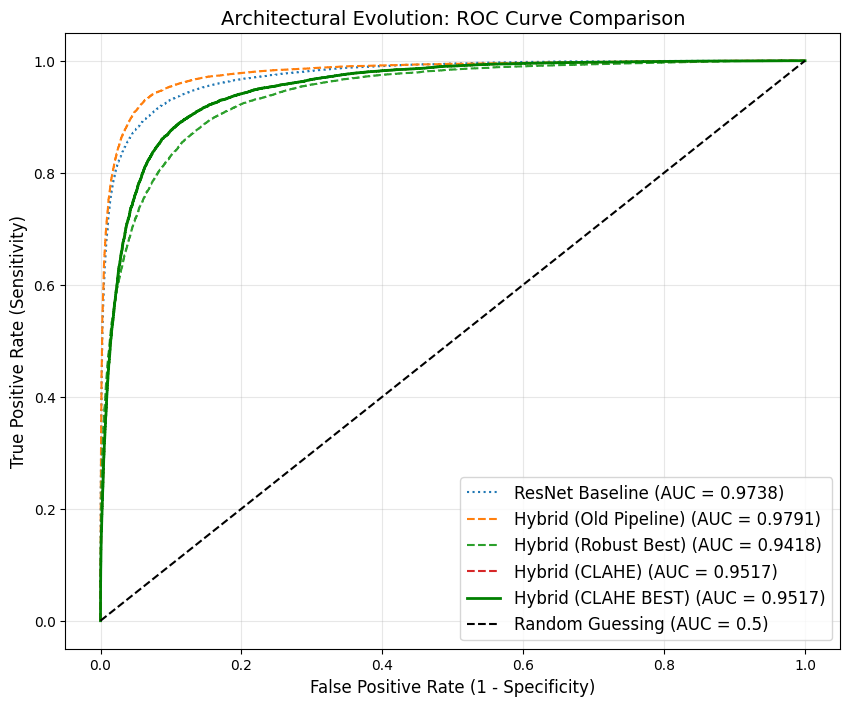

In [ ]:
# Generate Predictions
print("Generating predictions (This takes a few minutes)...")
preds_resnet = model_resnet.predict(val_ds).flatten()
preds_hybrid_old = model_hybrid_old_pipeline.predict(val_ds).flatten()
preds_hybrid_best = model_hybrid_new_pipeline.predict(val_ds).flatten()
preds_hybrid_clahe = model_hybrid_clahe.predict(val_ds).flatten()
preds_hybrid_clahe_best = model_hybrid_clahe_best.predict(val_ds).flatten()

# Calculate ROC and AUC
fpr_res, tpr_res, _ = roc_curve(y_true, preds_resnet)
auc_res = auc(fpr_res, tpr_res)

fpr_old, tpr_old, _ = roc_curve(y_true, preds_hybrid_old)
auc_old = auc(fpr_old, tpr_old)

fpr_best, tpr_best, _ = roc_curve(y_true, preds_hybrid_best)
auc_best = auc(fpr_best, tpr_best)

fpr_clahe, tpr_clahe, _ = roc_curve(y_true, preds_hybrid_clahe)
auc_clahe = auc(fpr_clahe, tpr_clahe)

fpr_clahe_best, tpr_clahe_best, _ = roc_curve(y_true, preds_hybrid_clahe_best)
auc_clahe_best = auc(fpr_clahe_best, tpr_clahe_best)

# Graphical Comprobation: Comparative ROC Curve
plt.figure(figsize=(10, 8))
plt.plot(fpr_res, tpr_res, label=f'ResNet Baseline (AUC = {auc_res:.4f})', linestyle=':')
plt.plot(fpr_old, tpr_old, label=f'Hybrid (Old Pipeline) (AUC = {auc_old:.4f})', linestyle='--')
plt.plot(fpr_best, tpr_best, label=f'Hybrid (Robust Best) (AUC = {auc_best:.4f})', linestyle='--')
plt.plot(fpr_clahe, tpr_clahe, label=f'Hybrid (CLAHE) (AUC = {auc_clahe:.4f})', linestyle='--')
plt.plot(fpr_clahe_best, tpr_clahe_best, label=f'Hybrid (CLAHE BEST) (AUC = {auc_clahe_best:.4f})', linewidth=2, color='green')
plt.plot([0, 1], [0, 1], 'k--', label='Random Guessing (AUC = 0.5)')
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
plt.ylabel('True Positive Rate (Sensitivity)', fontsize=12)
plt.title('Architectural Evolution: ROC Curve Comparison', fontsize=14)
plt.legend(loc='lower right', fontsize=12)
plt.grid(alpha=0.3)
plt.show()

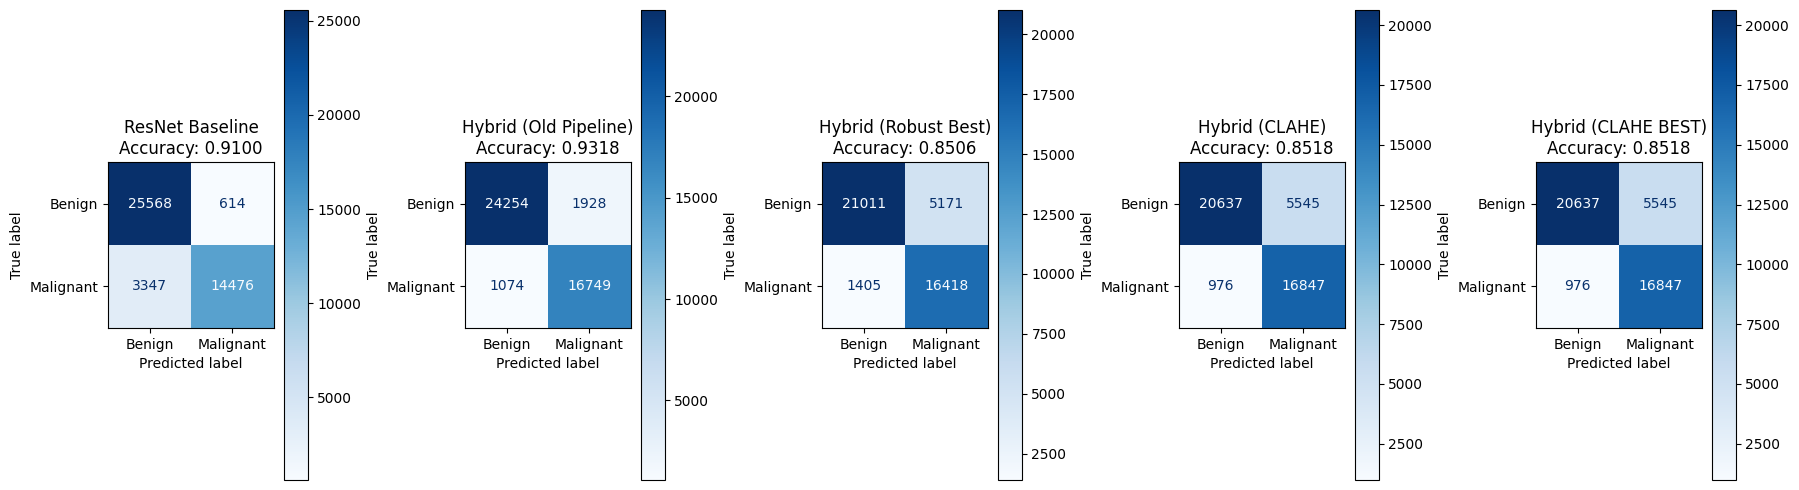

In [ ]:
# Graphical Comprobation: Confussion Matrices
fig, axes = plt.subplots(1, 5, figsize=(18, 5))
models_data = [
    ("ResNet Baseline", preds_resnet),
    ("Hybrid (Old Pipeline)", preds_hybrid_old),
    ("Hybrid (Robust Best)", preds_hybrid_best),
    ("Hybrid (CLAHE)", preds_hybrid_clahe),
    ("Hybrid (CLAHE BEST)", preds_hybrid_clahe_best)
]

for idx, (title, preds) in enumerate(models_data):
    binary_preds = (preds > 0.5).astype(int) 
    cm = confusion_matrix(y_true, binary_preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Benign', 'Malignant'])
    disp.plot(ax=axes[idx], cmap='Blues', values_format='d')
    axes[idx].set_title(f'{title}\nAccuracy: {(cm[0,0]+cm[1,1])/len(y_true):.4f}')

plt.tight_layout()
plt.show()

In [ ]:
# Calculate the metrics
def extract_metrics(y_true, y_pred_probs, threshold=0.5):
    # Calculate exact AUC
    auc_val = roc_auc_score(y_true, y_pred_probs)
    
    # Calculate exact Accuracy based on the threshold
    y_pred_binary = (y_pred_probs > threshold).astype(int)
    acc_val = accuracy_score(y_true, y_pred_binary)
    
    return auc_val, acc_val

# Extract metrics for all three models
auc_res, acc_res = extract_metrics(y_true, preds_resnet)
auc_old, acc_old = extract_metrics(y_true, preds_hybrid_old)
auc_best, acc_best = extract_metrics(y_true, preds_hybrid_best)
auc_clahe, acc_clahe = extract_metrics(y_true, preds_hybrid_clahe)
auc_clahe_best, acc_clahe_best = extract_metrics(y_true, preds_hybrid_clahe_best)


# Build the structured dictionary
results_data = {
    "Model Architecture": [
        "ResNet Baseline", 
        "Hybrid ResNet-ViT (Old Pipeline)", 
        "Hybrid ResNet-ViT (Robust Best Pipeline)",
        "Hybrid ResNet-ViT (CLAHE Preprocess)",
        "Hybrid ResNet-ViT (CLAHE Preprocess Best Epoch Model)"
    ],
    "ROC-AUC Score": [auc_res, auc_old, auc_best, auc_clahe, auc_clahe_best],
    "Accuracy (Threshold=0.5)": [acc_res, acc_old, acc_best, acc_clahe, acc_clahe_best]
}

# Convert to a Pandas DataFrame
results_table = pd.DataFrame(results_data)

# Round the numbers to 4 decimal places so it looks professional
results_table["ROC-AUC Score"] = results_table["ROC-AUC Score"].round(4)
results_table["Accuracy (Threshold=0.5)"] = results_table["Accuracy (Threshold=0.5)"].round(4)

# Display the table in the notebook
print("\n--- FINAL MODEL COMPARISON TABLE ---\n")
display(results_table)

# Save to disk for your project report
results_table.to_csv("/kaggle/working/model_comparison_table.csv", index=False)
print("\nTable successfully saved to /kaggle/working/model_comparison_table.csv")


--- FINAL MODEL COMPARISON TABLE ---



,Model Architecture,ROC-AUC Score,Accuracy (Threshold=0.5)
0,ResNet Baseline,0.9738,0.9100
1,Hybrid ResNet-ViT (Old Pipeline),0.9791,0.9318
2,Hybrid ResNet-ViT (Robust Best Pipeline),0.9418,0.8506
3,Hybrid ResNet-ViT (CLAHE Preprocess),0.9517,0.8518
4,Hybrid ResNet-ViT (CLAHE Preprocess Best Epoch...,0.9517,0.8518



Table successfully saved to /kaggle/working/model_comparison_table.csv


--- VISUAL SANITY CHECK (6 RANDOM IMAGES) ---
Running inference on 6 random sample images...


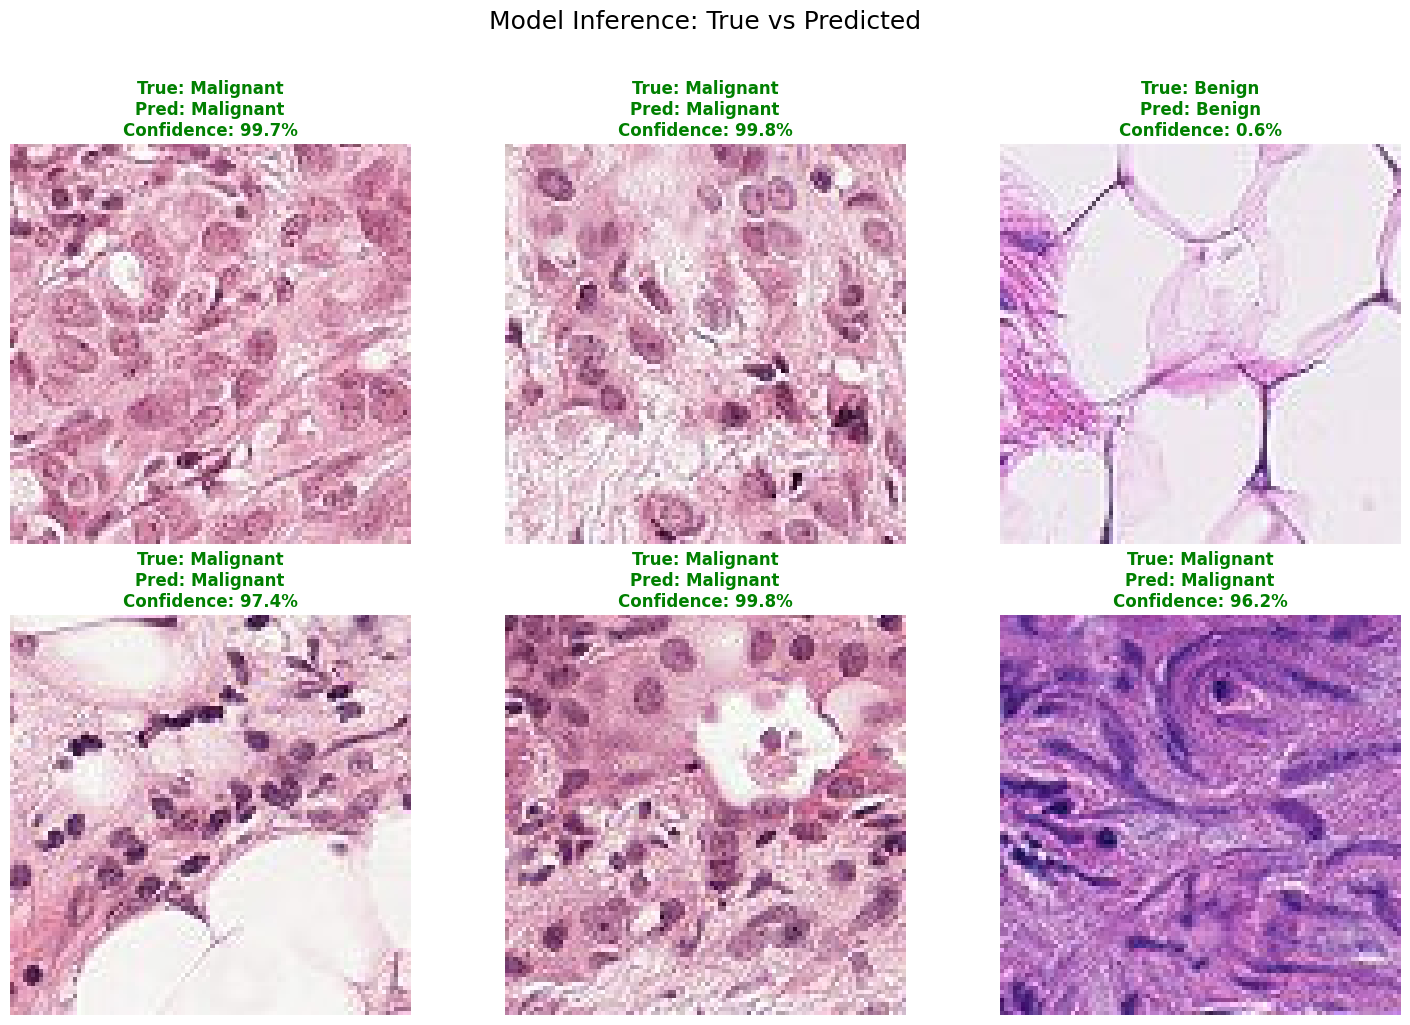

In [ ]:
print("--- VISUAL SANITY CHECK (6 RANDOM IMAGES) ---")

# Extract exactly one batch from the validation dataset
for images, labels in val_ds.take(1):
    # Pick 6 completely random indices from the batch
    random_indices = random.sample(range(images.shape[0]), 6)
    
    # Extract those 6 specific random images and labels
    sample_images = tf.gather(images, random_indices)
    sample_labels = tf.gather(labels, random_indices)
    break 

# Generate predictions for these 6 random images
print("Running inference on 6 random sample images...")
sample_preds = model_hybrid_clahe_best.predict(sample_images, verbose=0).flatten()

# Visualization Setup (2 rows, 3 columns)
class_names = ['Benign', 'Malignant']
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
fig.suptitle("Model Inference: True vs Predicted", fontsize=18, y=1.02)

# Flatten the axes array to easily loop through it (from 2D to 1D)
axes = axes.flatten()

# Plot the images and labels
for i in range(6):
    img = sample_images[i].numpy()
    true_label = sample_labels[i].numpy()
    
    pred_prob = sample_preds[i]
    pred_label = int(pred_prob > 0.5)
    
    text_color = 'green' if true_label == pred_label else 'red'
    
    axes[i].imshow(img)
    axes[i].axis('off')
    
    title_str = (f"True: {class_names[true_label]}\n"
                 f"Pred: {class_names[pred_label]}\n"
                 f"Confidence: {pred_prob:.1%}")
    axes[i].set_title(title_str, color=text_color, fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()